# Chapter 5 Notebook: AR, MA, ARMA Models
1. Import Libraries
We start by loading all required libraries for time series analysis and visualization.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

!pip install yfinance
import warnings
warnings.filterwarnings("ignore")




[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset (Air Passengers)
We use a real-world dataset of monthly airline passengers to study time series behavior.

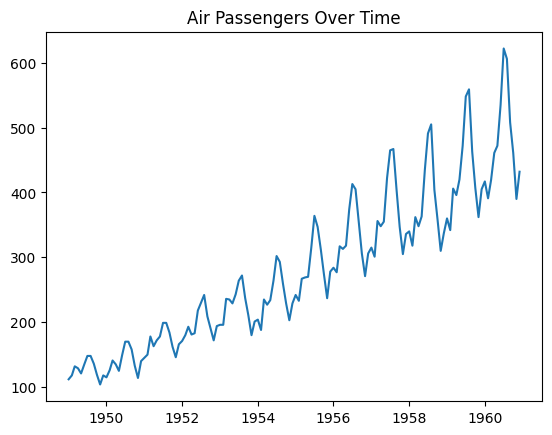

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("airline-passengers.csv")

df.columns = ["Month", "Passengers"]
df["Month"] = pd.to_datetime(df["Month"])
df.to_csv("airline-passengers.csv", index= False)
df.set_index("Month", inplace=True)

ts = df["Passengers"]

plt.plot(ts)
plt.title("Air Passengers Over Time")
plt.show()

## 3. Stationarity Check (ADF Test)
Before modeling, we check whether the data is stable over time.

In [20]:
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060352
p-value: 0.9918802434376408


## 4. Differencing (Make Series Stationary)
If the data is not stationary, we remove trend using differencing.

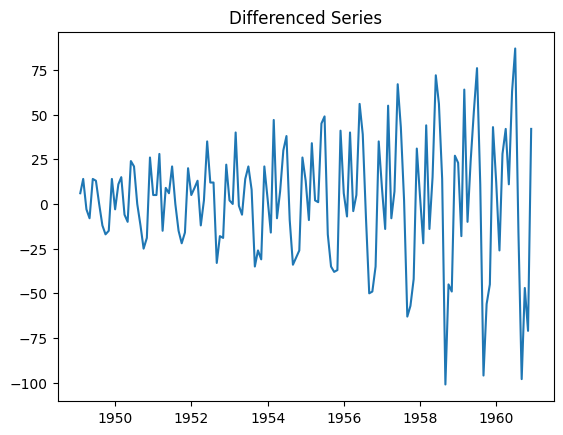

In [21]:
ts_diff = ts.diff().dropna()

plt.plot(ts_diff)
plt.title("Differenced Series")
plt.show()

#### Recheck stationarity:

In [22]:
adfuller(ts_diff)[1]

0.05421329028382621

## 5. ACF & PACF Analysis
These plots help us identify whether AR or MA structure exists.

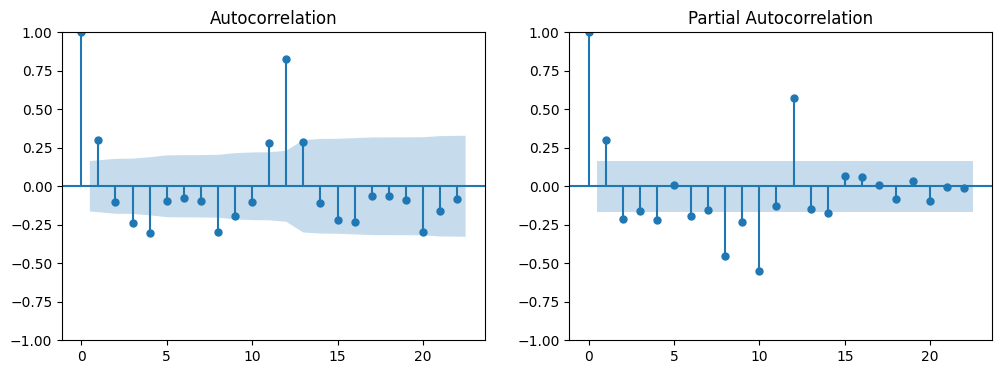

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(ts_diff, ax=ax[0])
plot_pacf(ts_diff, ax=ax[1])

plt.show()

## 6. Random Walk Simulation
A random walk has no memory structure and is driven only by noise.

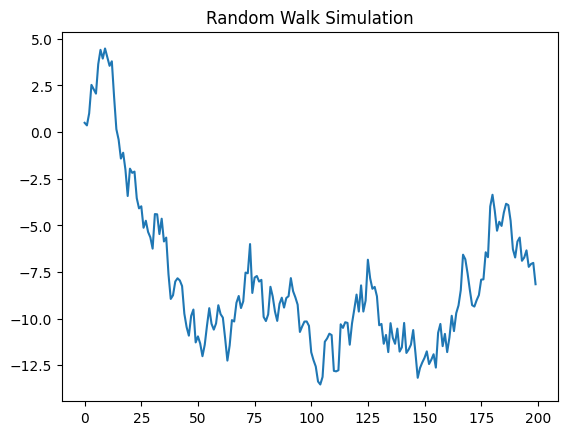

In [24]:
np.random.seed(42)

n = 200
noise = np.random.normal(0, 1, n)

random_walk = np.cumsum(noise)

plt.plot(random_walk)
plt.title("Random Walk Simulation")
plt.show()

## Stock Data + Random Walk Comparison
Install and Load Real Stock Data (Example: Apple)


[*********************100%***********************]  1 of 1 completed


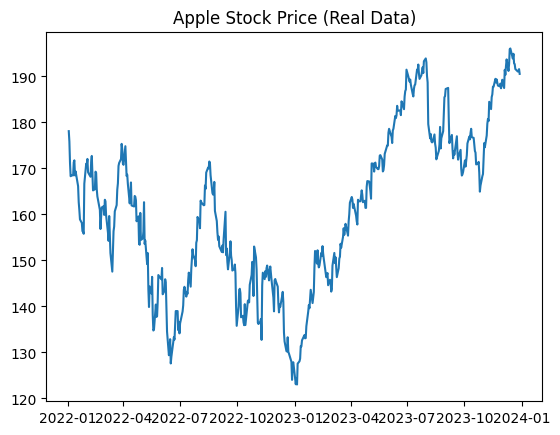

In [25]:

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# Download stock data
data = yf.download("AAPL", start="2022-01-01", end="2024-01-01")

stock = data["Close"]

plt.plot(stock)
plt.title("Apple Stock Price (Real Data)")
plt.show()

## 7. Autoregressive (AR) Model
AR model uses past values to predict the future.

In [26]:
# AR model assumes current value depends on previous 2 observations
model_ar = AutoReg(ts, lags=2).fit()

print(model_ar.summary())

                            AutoReg Model Results                             
Dep. Variable:             Passengers   No. Observations:                  144
Model:                     AutoReg(2)   Log Likelihood                -691.539
Method:               Conditional MLE   S.D. of innovations             31.534
Date:                Thu, 07 May 2026   AIC                           1391.079
Time:                        00:16:27   BIC                           1402.902
Sample:                    03-01-1949   HQIC                          1395.883
                         - 12-01-1960                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            16.4821      6.811      2.420      0.016       3.134      29.831
Passengers.L1     1.2766      0.080     16.009      0.000       1.120       1.433
Passengers.L2    -0.3298      0.079     

### Forecasting AR model:

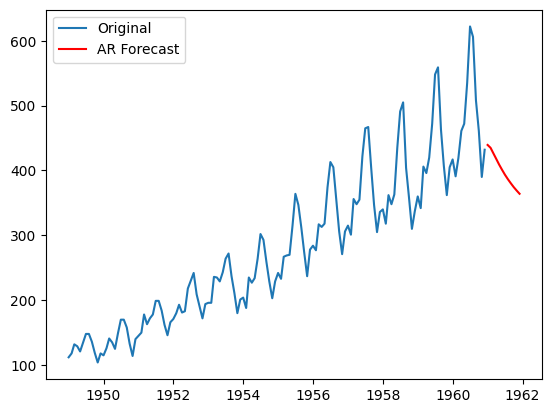

In [27]:
forecast_ar = model_ar.predict(start=len(ts), end=len(ts)+11)

plt.plot(ts, label="Original")
plt.plot(forecast_ar, label="AR Forecast", color="red")
plt.legend()
plt.show()

## 8. Moving Average (MA) Simulation (Simple Intuition)
MA model is based on past random shocks (noise).

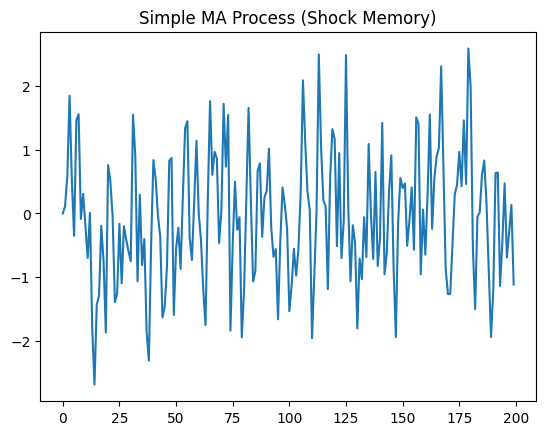

In [28]:
np.random.seed(42)

n = 200
noise = np.random.normal(0, 1, n)

ma_series = np.zeros(n)

for i in range(1, n):
    ma_series[i] = noise[i] + 0.5 * noise[i-1]

plt.plot(ma_series)
plt.title("Simple MA Process (Shock Memory)")
plt.show()

## 9. ACF for MA Process
MA behavior is identified using ACF (not PACF).

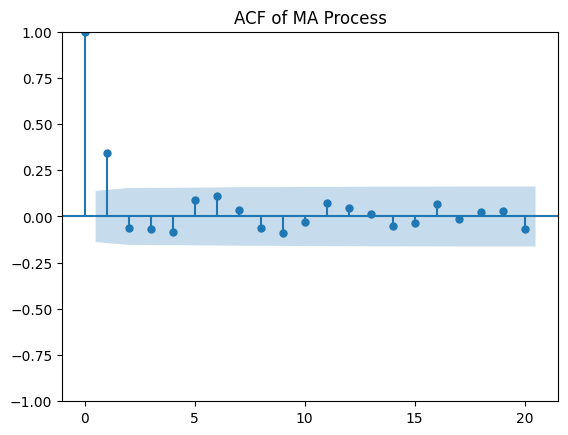

In [29]:
plot_acf(ma_series, lags=20)

plt.title("ACF of MA Process")
plt.show()

## 10. ARMA Simulation (Combined Idea)
ARMA combines both past values and past shocks.

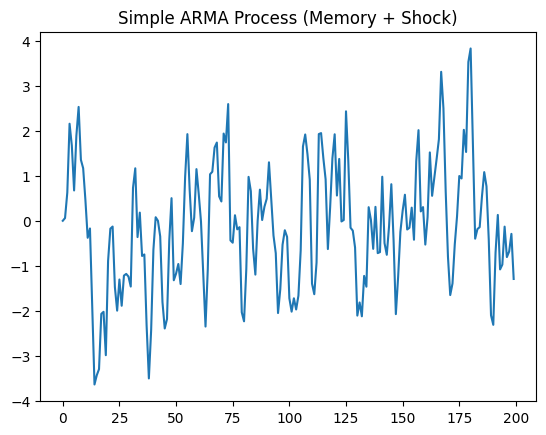

In [30]:
np.random.seed(42)

n = 200
noise = np.random.normal(0, 1, n)

arma_series = np.zeros(n)

for t in range(1, n):
    ar_part = 0.6 * arma_series[t-1]
    ma_part = 0.4 * noise[t-1]
    
    arma_series[t] = ar_part + ma_part + noise[t]

plt.plot(arma_series)
plt.title("Simple ARMA Process (Memory + Shock)")
plt.show()

## 11. Model Comparison Table (Code View)
Quick reference for understanding model behavior.

In [31]:
import pandas as pd

table = pd.DataFrame({
    "Model": ["AR", "MA", "Random Walk", "ARMA"],
    "Driven By": ["Past values", "Past shocks", "Last value + noise", "Both values + shocks"],
    "Memory Type": ["Structural", "Noise", "None", "Mixed"]
})

table

,Model,Driven By,Memory Type
0,AR,Past values,Structural
1,MA,Past shocks,Noise
2,Random Walk,Last value + noise,None
3,ARMA,Both values + shocks,Mixed


## 12. Final Insight Plot (Optional Recap)
Visual summary of all behaviors.

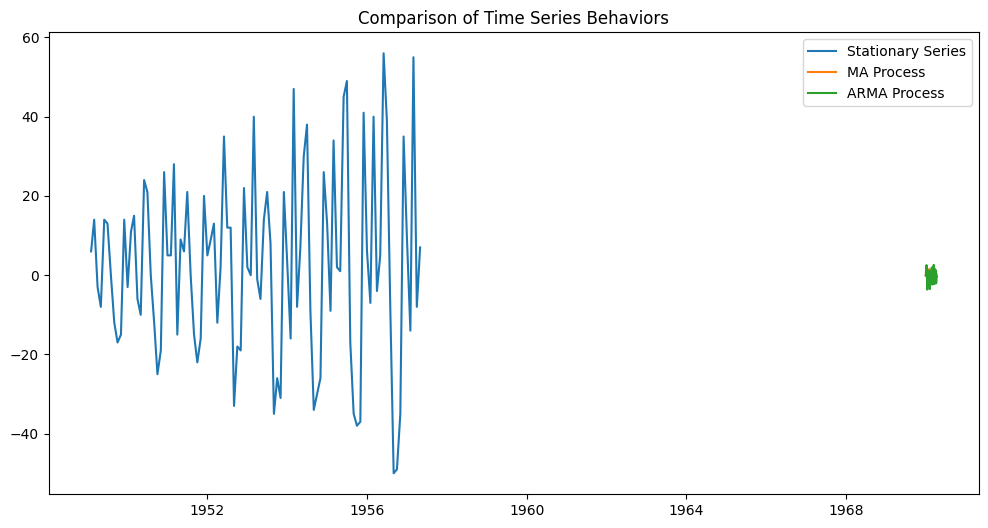

In [32]:
plt.figure(figsize=(12,6))

plt.plot(ts_diff[:100], label="Stationary Series")
plt.plot(ma_series[:100], label="MA Process")
plt.plot(arma_series[:100], label="ARMA Process")

plt.legend()
plt.title("Comparison of Time Series Behaviors")
plt.show()

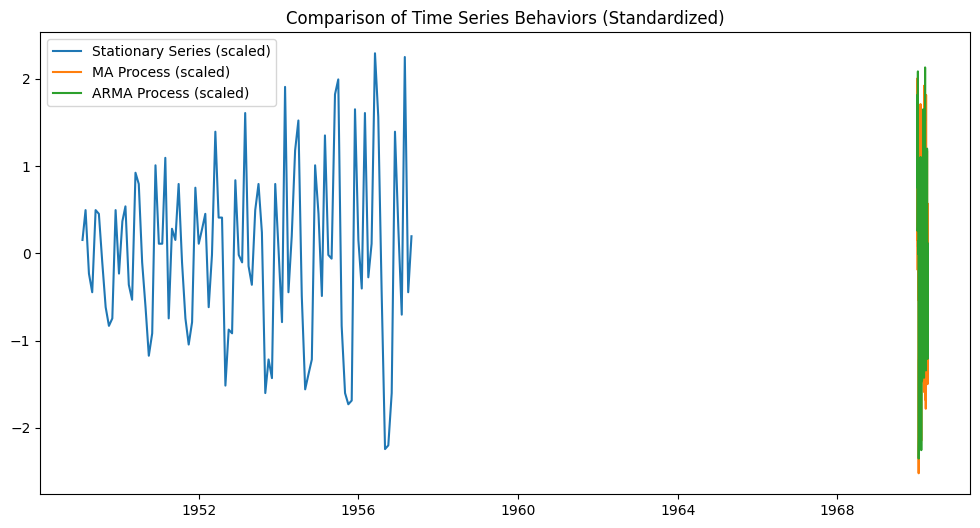

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Standardize all series (makes them comparable)
ts_plot = (ts_diff[:100] - np.mean(ts_diff[:100])) / np.std(ts_diff[:100])
ma_plot = (ma_series[:100] - np.mean(ma_series[:100])) / np.std(ma_series[:100])
arma_plot = (arma_series[:100] - np.mean(arma_series[:100])) / np.std(arma_series[:100])

plt.figure(figsize=(12,6))

plt.plot(ts_plot, label="Stationary Series (scaled)")
plt.plot(ma_plot, label="MA Process (scaled)")
plt.plot(arma_plot, label="ARMA Process (scaled)")

plt.legend()
plt.title("Comparison of Time Series Behaviors (Standardized)")
plt.show()

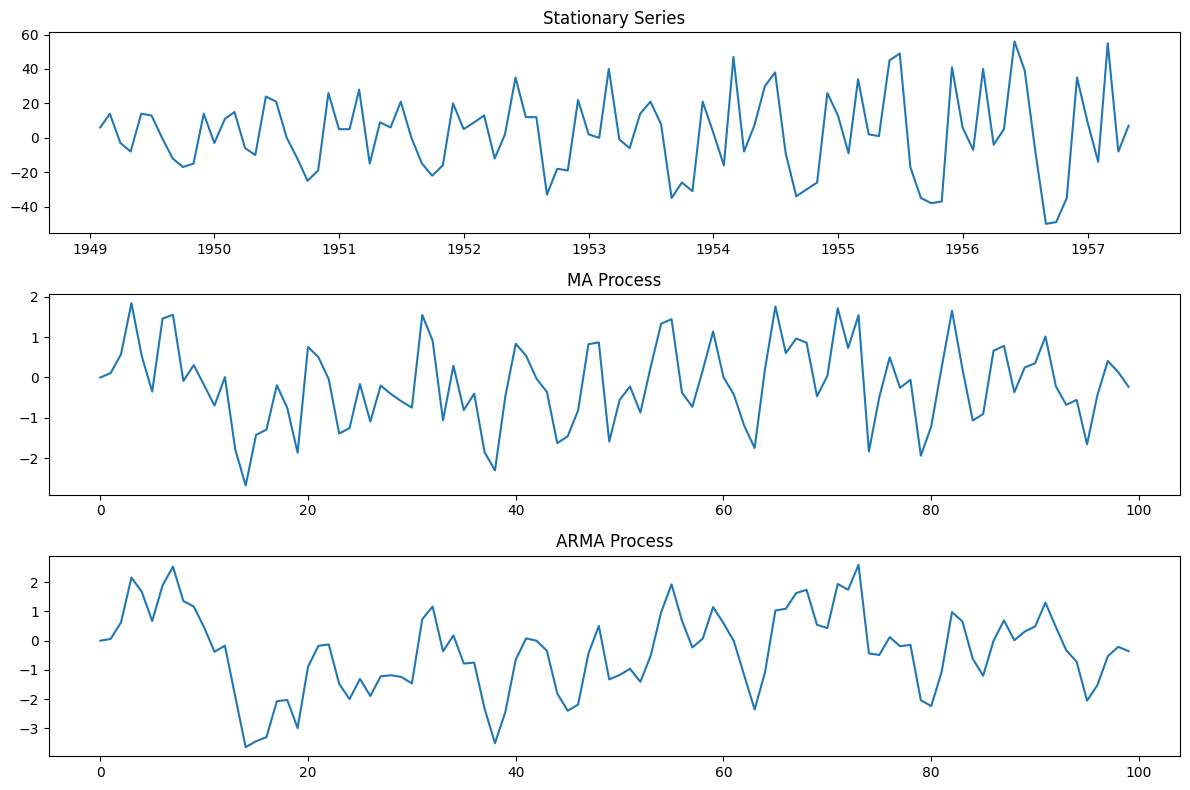

In [34]:
fig, ax = plt.subplots(3, 1, figsize=(12,8))

ax[0].plot(ts_diff[:100])
ax[0].set_title("Stationary Series")

ax[1].plot(ma_series[:100])
ax[1].set_title("MA Process")

ax[2].plot(arma_series[:100])
ax[2].set_title("ARMA Process")

plt.tight_layout()
plt.show()